# MiBiReMo Example 4: Field installation tracer test

An in situ biological flushing installation is modelled with one extraction well (EXT_1) and four injection wells (INJ_1–4) at the
corners of a square at a distance of 4 m from the extraction well. The model consists of a single-layer aquifer with uniform properties. 
The hydraulic gradient is assumed to be constant throughout the domain, with a direction from west to east. The groundwater elevation is 93.7 m a.s.l.
at the EXT_1 well when pumping is not active. The wells are all screened over the aquifer, from 95.5 to 90.5 m a.s.l.
The extraction well pumps four times the rate of each injection well, so the total injected water volume corresponds to the volume pumped by the extraction well.

A tracer is injected during the first day at a concentration of 1.0 g m⁻³. The class `FieldModel` is used to build a MODFLOW 6 model through flopy,
using groundwater flow (GWF), and tracer transport (GWT) packages.

MODFLOW 6 is required for running this notebook. Please install it using `get-modflow :python --subset mf6,libmf6`.

In [1]:
from dataclasses import replace
from pathlib import Path
import matplotlib.pyplot as plt
import mibiremo as mb

HOUR, DAY = 3600.0, 86400.0
OUTPUT = (Path(__file__).parent if "__file__" in globals() else Path()) / "output"  # next to this script or notebook

## Wells

The object of class `Well` contains the well geometry (location, well and screen elevations, diameter). 
One object is created for the extraction well, and the injection wells are created as copies of the extraction well on a circle
using the `array_radial` function.
Wells can also be read from a shapefile or a CSV file (`read_wells`), or written to a file (`write_wells`).
Flow rates Q [m³ s⁻¹] are associated to each well by their name. Positive flow indicates injection, negative for extraction.

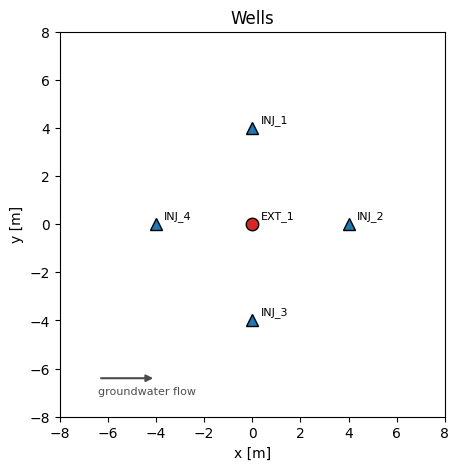

In [2]:
extraction = mb.Well(
    "EXT_1", x=0.0, y=0.0, well_top=96.3, well_bottom=90.5, diameter=0.1, screen_top=95.5, screen_bottom=90.5
)
injection = mb.array_radial(replace(extraction, name="INJ"), n_wells=4, radius=4.0)
wells = [extraction, *injection]

Q = 2.9e-5  # flow rate of each injection well [m3 s-1], 2.5 m3/d
flow_rates = {"EXT_1": -4 * Q} | {w.name: Q for w in injection}

fig, ax = plt.subplots(figsize=(5, 5))
mb.plotting.wells(ax, wells, flow_rates)
ax.set(xlim=(-8, 8), ylim=(-8, 8), xlabel="x [m]", ylabel="y [m]", title="Wells")
mb.plotting.flow_arrow(ax, 90.0)
plt.show()

## Model setup and simulation

The aquifer is homogeneous and confined. The groundwater flows from west to east (azimuth 90°) with a hydraulic
gradient of 0.01 m/m, imposed by fixed heads on the lateral boundary. The grid is refined around the wells (0.5 m
cells, growing to 4 m). Flow is steady within each stress period. Time-dependent inputs are defined as schedules
`[(t, value), ...]` with t in seconds. Here, the tracer concentration of the injected water C_in (1 during the first
day, then 0) and the time step (1 h during the tracer injection, then 4 h). The stress periods are derived from the
change times of all schedules.

With C_in = 1 and tracer-free groundwater, the concentration C equals the fraction of injected water.

In [3]:
model = mb.FieldModel(
    workspace=OUTPUT / "ex4",
    wells=wells,
    flow_rates=flow_rates,
    domain_size=(100.0, 100.0),
    top=95.5,
    bottom=90.5,
    hydraulic_conductivity=5e-6,
    porosity=0.25,
    reference_head=93.7,
    regional_hydraulic_gradient=0.01,
    regional_flow_azimuth=90.0,
    tracer_concentration=[(0.0, 1.0), (DAY, 0.0)],
    grid_spacing=4.0,
    grid_spacing_at_wells=0.5,
    simulation_time=30 * DAY,
    time_step=[(0.0, HOUR), (DAY, 4 * HOUR)],
)
model.stress_periods

,start,duration,n_time_steps,EXT_1,INJ_1,INJ_2,INJ_3,INJ_4,tracer_concentration
0,0.0,86400.0,24,-0.000116,0.000029,0.000029,0.000029,0.000029,1.0
1,86400.0,2505600.0,174,-0.000116,0.000029,0.000029,0.000029,0.000029,0.0


In [4]:
model.run()
print(f"Grid: {model.grid.nrow} rows x {model.grid.ncol} columns x {model.grid.nlay} layer")

Grid: 63 rows x 63 columns x 1 layer


## Hydraulic head

The flopy simulation is available in `model.simulation`; results are read with `head`, `concentration`,
`well_concentration`, and `mass_balance` (times in seconds). The drawdown is calculated as the difference from the head of the
groundwater flow without pumping.

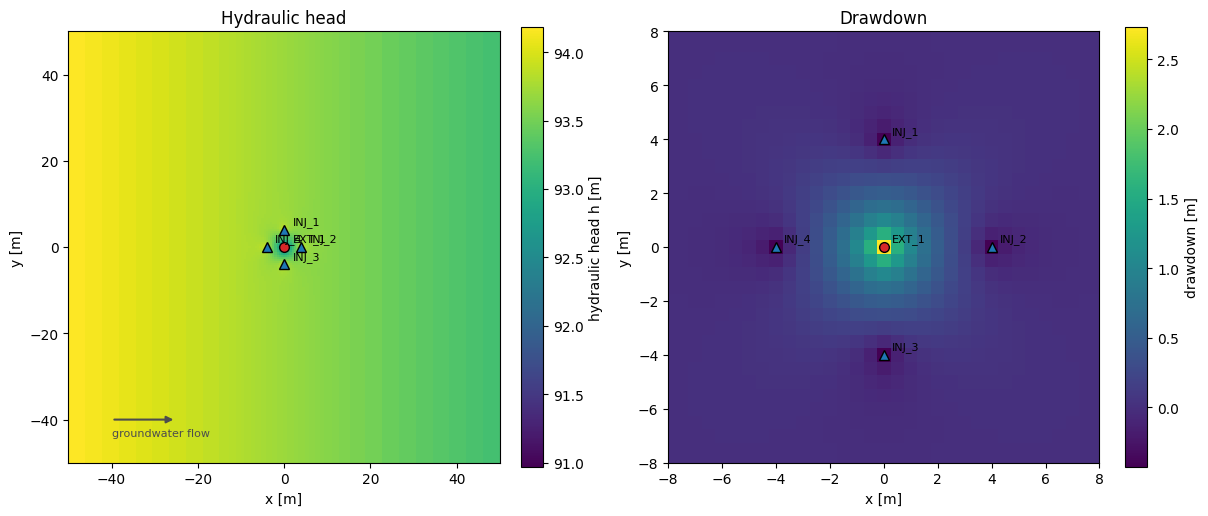

In [5]:
head = model.head()
drawdown = model.head_from_gradient(model.grid.xcellcenters, model.grid.ycellcenters) - head
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
mb.plotting.map_view(model, head, label="hydraulic head h [m]", ax=axes[0])
mb.plotting.flow_arrow(axes[0], 90.0)
axes[0].set_title("Hydraulic head")
mb.plotting.map_view(model, drawdown, label="drawdown [m]", ax=axes[1])
axes[1].set(xlim=(-8, 8), ylim=(-8, 8), title="Drawdown")
plt.show()

## Tracer

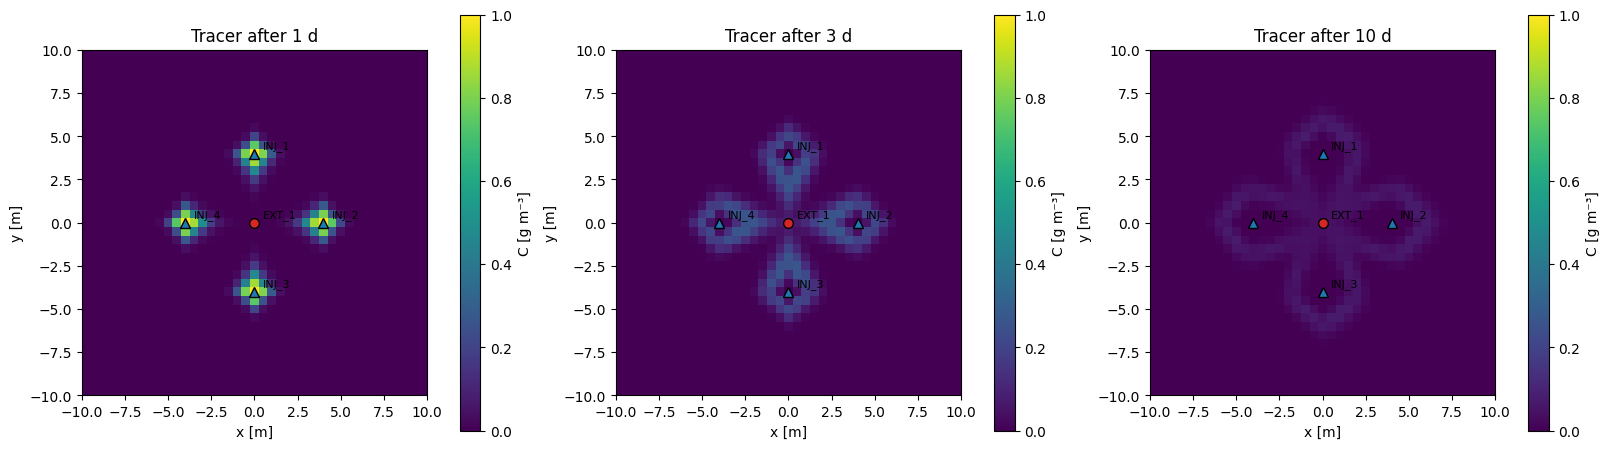

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), layout="constrained")
for ax, days in zip(axes, [1, 3, 10]):
    mb.plotting.map_view(model, model.concentration(days * DAY), label="C [g m⁻³]", ax=ax, vmin=0, vmax=1)
    ax.set(xlim=(-10, 10), ylim=(-10, 10), title=f"Tracer after {days} d")
plt.show()

## Breakthrough curve and mass recovery

The well concentration is calculated as the flow-weighted mean over the screened cells. The mass balance comes from the MODFLOW
budget, calculated as the tracer extracted by EXT_1 as a fraction of the total injected tracer mass.

Peak C = 0.112 g/m3 at 4.8 d, tracer mass recovered after 30 d: 86%


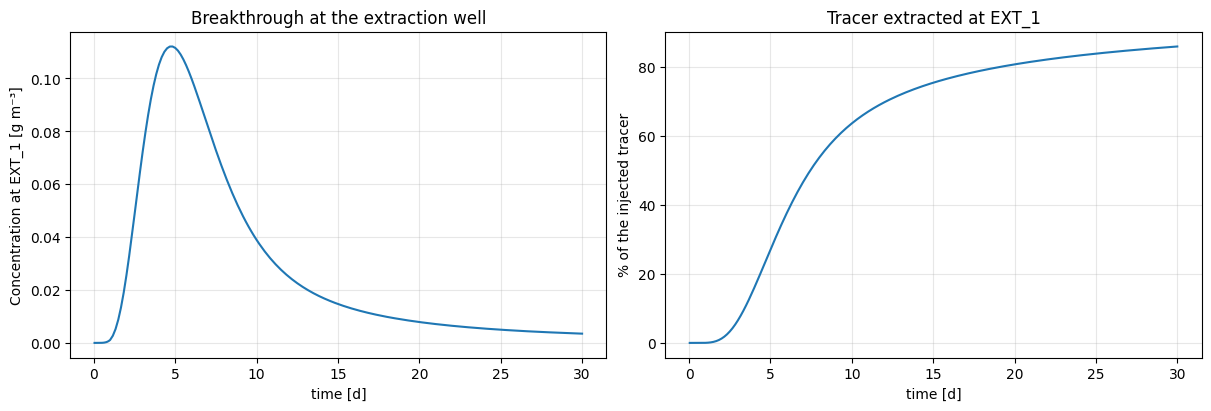

In [7]:
curve = model.well_concentration("EXT_1")
balance = model.mass_balance()
peak = curve.loc[curve["concentration"].idxmax()]
recovered = balance["extracted"].iloc[-1] / balance["injected"].iloc[-1]
print(f"Peak C = {peak['concentration']:.3f} g/m3 at {peak['time'] / DAY:.1f} d, tracer mass recovered after 30 d: {recovered:.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(curve["time"] / DAY, curve["concentration"])
axes[0].set(xlabel="time [d]", ylabel="Concentration at EXT_1 [g m⁻³]", title="Breakthrough at the extraction well")
axes[1].plot(balance["time"] / DAY, 100 * balance["extracted"] / balance["injected"].iloc[-1])
axes[1].set(xlabel="time [d]", ylabel="% of the injected tracer", title="Tracer extracted at EXT_1")
for ax in axes:
    ax.grid(alpha=0.3)
plt.show()

Further options of `FieldModel` are: time-dependent flow rates (schedules, e.g. `mb.intermittent_pumping`), multiple layers
(`n_layers`, `vertical_anisotropy`) for partially screened wells, dispersion (`dispersion=True` with
dispersivities), the advection scheme, and reactive transport with PHREEQC coupling. See next examples for more details.